In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots


In [2]:
df_tfd_base1 = pd.read_csv('../../cp/results_base1_tfd.csv')
df_tfd_base1 = df_tfd_base1.drop_duplicates(subset=['config','num_trains'])
df_tfd_base1 = df_tfd_base1.assign(planner='tfd', base='base1')

df_tfd_base2 = pd.read_csv('../../cp/results_base2_tfd.csv')
df_tfd_base2 = df_tfd_base2.drop_duplicates(subset=['config','num_trains'])
df_tfd_base2 = df_tfd_base2.assign(planner='tfd', base='base2')

df_tfd = pd.concat([df_tfd_base1, df_tfd_base2])

df_enhsp_base3 = pd.read_csv('../../cp/results_base3_enhsp.csv')
df_enhsp_base3 = df_enhsp_base3.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base3 = df_enhsp_base3.assign(planner='enhsp', base='base3')

df_enhsp_base4 = pd.read_csv('../../cp/results_base4_enhsp.csv')
df_enhsp_base4 = df_enhsp_base4.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base4 = df_enhsp_base4.assign(planner='enhsp', base='base4')

df_enhsp = pd.concat([df_enhsp_base3, df_enhsp_base4])

df_mff_base3 = pd.read_csv('../../cp/results_base3_metricff.csv')
df_mff_base3 = df_mff_base3.drop_duplicates(subset=['config','num_trains'])
df_mff_base3 = df_mff_base3.assign(planner='metricff', base='base3')

df_mff = df_mff_base3.copy()

df_nfd_base3 = pd.read_csv('../../cp/results_base3_nfd.csv')
df_nfd_base3 = df_nfd_base3.drop_duplicates(subset=['config','num_trains'])
df_nfd_base3 = df_nfd_base3.assign(planner='nfd', base='base3')

# df_nfd_base4 = pd.read_csv('../../cp/results_base4_nfd.csv')
# df_nfd_base4 = df_nfd_base4.drop_duplicates(subset=['config','num_trains'])
# df_nfd_base4 = df_nfd_base4.assign(planner='nfd', base='base4')

df_nfd = pd.concat([df_nfd_base3])#, df_nfd_base4])

df_base1 = df_tfd_base1.copy()
df_base2 = df_tfd_base2.copy()
df_base3 = pd.concat([df_enhsp_base3, df_mff_base3, df_nfd_base3])
df_base4 = pd.concat([df_enhsp_base4])#, df_nfd_base4])

df_temporal = pd.concat([df_base1, df_base2])
df_numeric = pd.concat([df_base3, df_base4])


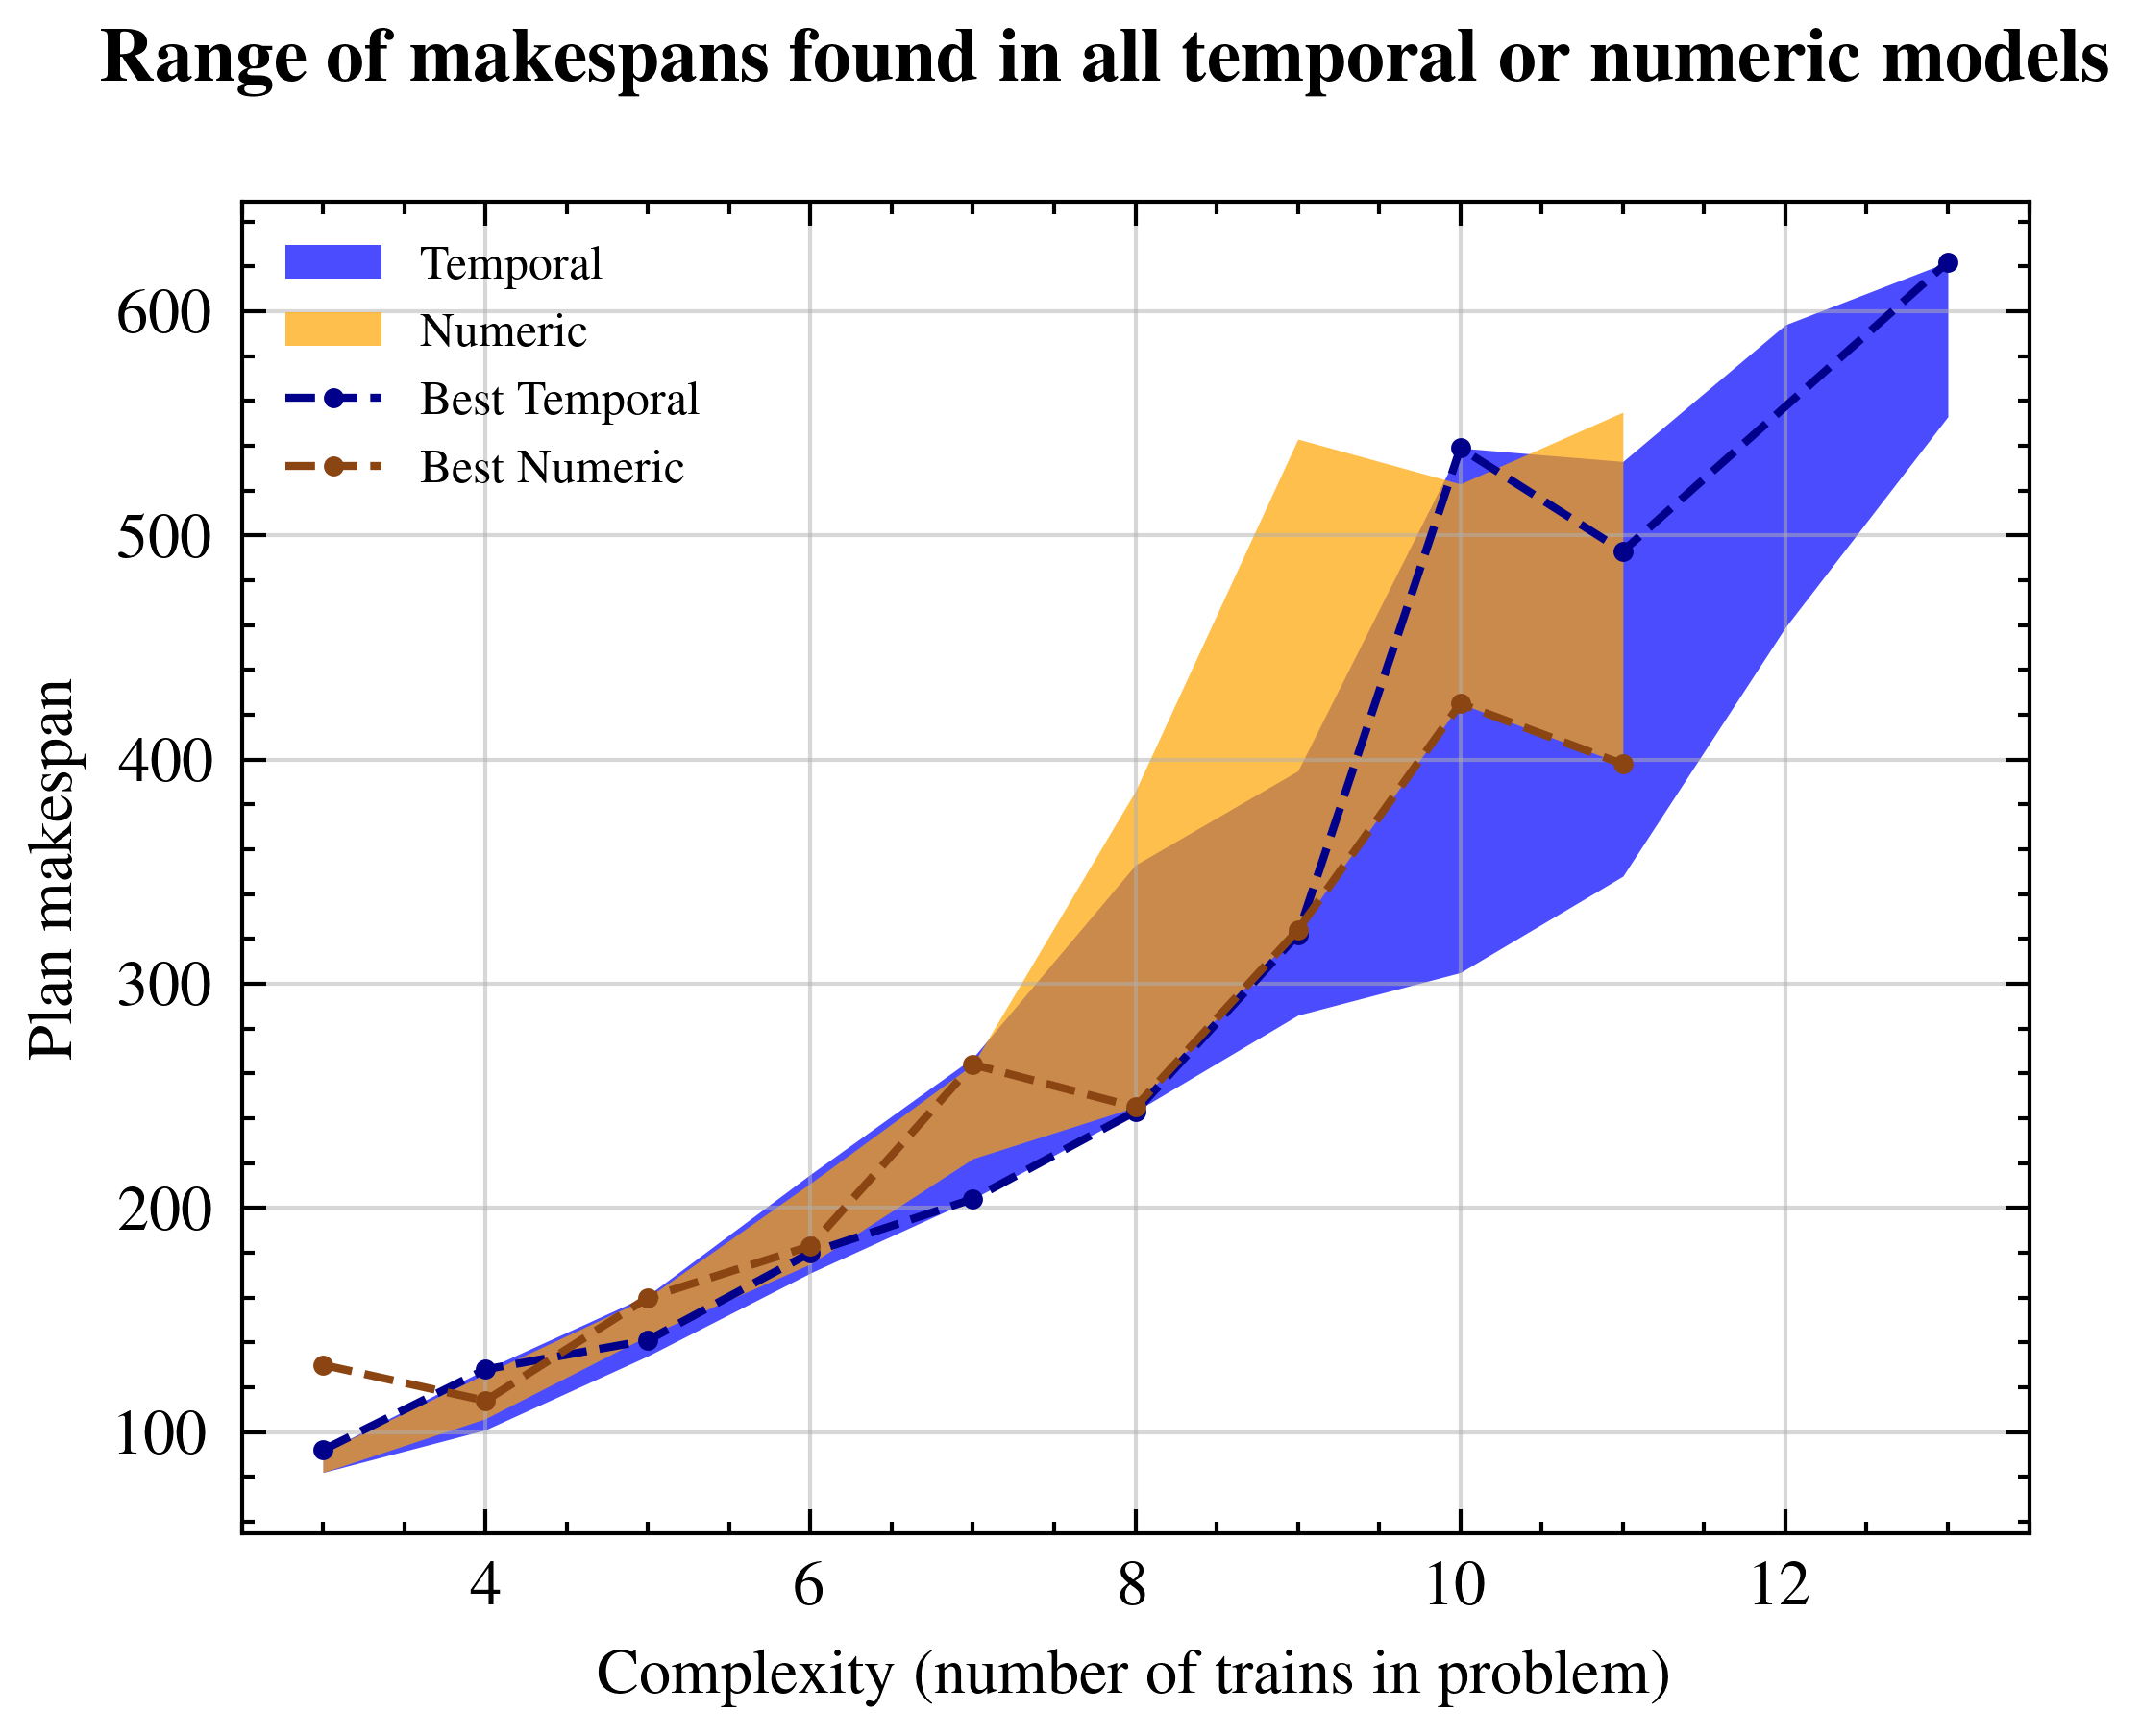

In [20]:
temporal_y1, temporal_y2 = [], []
numeric_y1, numeric_y2 = [], []
temporal_x = []
numeric_x = []

for i in range(3,20):
    df_temporal_filt = df_temporal.query(f"num_trains=={i}")
    temporal_sorted_makespans = sorted(df_temporal_filt['makespan_pp'])
    max_idx = min(len(temporal_sorted_makespans)-1,9)
    if len(temporal_sorted_makespans)> 0:
        temporal_y1.append(temporal_sorted_makespans[0])
        temporal_y2.append(temporal_sorted_makespans[max_idx])
        temporal_x.append(i)

    df_numeric_filt = df_numeric.query(f"num_trains=={i}")
    numeric_sorted_makespans = sorted(df_numeric_filt['makespan_pp'])
    max_idx = min(len(numeric_sorted_makespans)-1,9)
    if len(numeric_sorted_makespans)> 0:
        numeric_y1.append(numeric_sorted_makespans[0])
        numeric_y2.append(numeric_sorted_makespans[max_idx])
        numeric_x.append(i)

df_best_temporal = df_tfd.query("base=='base1' and config==3")
df_best_numeric = df_enhsp.query("base=='base3' and config==6")

plt.style.use(['ieee', 'science'])

fig, ax = plt.subplots(figsize=(4,3))
fig.suptitle(r"""\textbf{Range of makespans found in all temporal or numeric models}""")
ax.fill_between(temporal_x, temporal_y1, temporal_y2, alpha=0.7, linewidth=0, label='Temporal', color='blue')
ax.fill_between(numeric_x, numeric_y1, numeric_y2, alpha=0.7, linewidth=0, label='Numeric', color='orange')
ax.plot(df_best_temporal['num_trains'], df_best_temporal['makespan_pp'], '.--', label='Best Temporal', color='darkblue', markersize=3)
ax.plot(df_best_numeric['num_trains'], df_best_numeric['makespan_pp'], '.--', label='Best Numeric', color='saddlebrown', markersize=3)
ax.grid(True, alpha=0.5)
ax.set_ylabel('Plan makespan')
ax.set_xlabel('Complexity (number of trains in problem)')
ax.legend(loc='upper left', fontsize=6)

# plt.tight_layout()

fig.savefig('temporal_vs_numeric.png')